In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve, roc_auc_score


# Import finalized feature data


In [2]:
data_file = "../processed_data/finalized_feature_data_2024-03-01_2026-05-02.csv"
feature_data = (
    pd.read_csv(data_file, parse_dates=["timestamp_utc"])
    .set_index("timestamp_utc")
    .sort_index()
)

# Keep the same interface as the TCN notebook.
feature_data["Day_of_week_sin"] = np.sin(2 * np.pi * feature_data["Day_of_week"] / 7)
feature_data["Day_of_week_cos"] = np.cos(2 * np.pi * feature_data["Day_of_week"] / 7)
feature_data["Month_sin"] = np.sin(2 * np.pi * feature_data["Month"] / 12)
feature_data["Month_cos"] = np.cos(2 * np.pi * feature_data["Month"] / 12)

observed_cols = [column for column in feature_data.columns if column.startswith("observed_")]
forecast_cols = [column for column in feature_data.columns if column.startswith("forecast_")]

feature_combined = feature_data.drop(columns=forecast_cols).copy()
forecast_data = feature_data[forecast_cols].copy()

display(feature_data.shape)
display(feature_combined.shape)
display(forecast_data.shape)


(18988, 63)

(18988, 43)

(18988, 20)

In [3]:
# Basic timestamp checks.
for name, df in {"feature_combined": feature_combined, "forecast_data": forecast_data}.items():
    if df.index.has_duplicates:
        raise ValueError(f"{name} has duplicated timestamps")

    hourly_steps = df.index.to_series().sort_values().diff().dropna()
    if not hourly_steps.eq(pd.Timedelta(hours=1)).all():
        raise ValueError(f"{name} is not continuous hourly data")


## Models:


In [4]:
# Config
lookback = 24
valid_start = pd.Timestamp("2025-07-01", tz="UTC")
test_start = pd.Timestamp("2025-12-01", tz="UTC")

hidden_dim = 64
num_layers = 1
dropout = 0.0
learning_rate = 0.001
batch_size = 64
epochs = 10
patience = 5
seeds = [1, 2, 3]


In [5]:
# Model input tables. Target time is t; SMARD and price history end at t-24.
target = feature_combined["Negative_price"].astype(int).sort_index()

calendar_cols = [
    "Hour",
    "Day_of_week",
    "Month",
    "Is_weekend",
    "Hour_sin",
    "Hour_cos",
    "Day_of_week_sin",
    "Day_of_week_cos",
    "Month_sin",
    "Month_cos",
]

observed_cols = [c for c in feature_combined.columns if c.startswith("observed_")]
forecast_cols = [c for c in forecast_data.columns if c.startswith("forecast_")]
smard_input_cols = [
    c for c in feature_combined.columns
    if c not in calendar_cols + ["Negative_price"] + observed_cols
]

observed_weather = feature_combined[observed_cols].rename(columns=lambda c: c.replace("observed_", ""))
forecast_weather = forecast_data[forecast_cols].rename(columns=lambda c: c.replace("forecast_", ""))

if sorted(observed_weather.columns) != sorted(forecast_weather.columns):
    raise ValueError("Observed and forecast weather columns do not match after removing prefixes")

weather_cols = observed_weather.columns.tolist()
feature_cols = calendar_cols + smard_input_cols + weather_cols

past_raw = pd.concat(
    [feature_combined[calendar_cols], feature_combined[smard_input_cols], observed_weather],
    axis=1,
).sort_index()

forecast_future_raw = (
    feature_combined[calendar_cols]
    .join(forecast_weather, how="inner")
    .reindex(columns=feature_cols)
    .sort_index()
)

oracle_future_raw = (
    feature_combined[calendar_cols]
    .join(observed_weather, how="inner")
    .reindex(columns=feature_cols)
    .sort_index()
)

pd.DataFrame({
    "table": ["past_raw", "forecast_future_raw", "oracle_future_raw"],
    "shape": [past_raw.shape, forecast_future_raw.shape, oracle_future_raw.shape],
    "start": [past_raw.index.min(), forecast_future_raw.index.min(), oracle_future_raw.index.min()],
    "end": [past_raw.index.max(), forecast_future_raw.index.max(), oracle_future_raw.index.max()],
})


,table,shape,start,end
0,past_raw,"(18988, 42)",2024-03-01 00:00:00+00:00,2026-05-01 03:00:00+00:00
1,forecast_future_raw,"(18988, 42)",2024-03-01 00:00:00+00:00,2026-05-01 03:00:00+00:00
2,oracle_future_raw,"(18988, 42)",2024-03-01 00:00:00+00:00,2026-05-01 03:00:00+00:00


In [6]:
# Scale with training-period statistics only.
train_rows = past_raw[past_raw.index < valid_start].reindex(columns=feature_cols)
feature_mean = train_rows.mean()
feature_std = train_rows.std().replace(0, 1).fillna(1)

def scale_features(df):
    return ((df.reindex(columns=feature_cols) - feature_mean) / feature_std).fillna(0.0)

past_scaled = scale_features(past_raw)
forecast_future_scaled = scale_features(forecast_future_raw)
oracle_future_scaled = scale_features(oracle_future_raw)


In [7]:
# Build sequences. Past part is t-(24+lookback-1)...t-24.
# If future_X is passed, append the deployable weather path t-23...t.
def build_sequences(X, y, future_X=None, lookback=24):
    Xs, ys, times = [], [], []

    X_values = X.to_numpy(dtype=np.float32)
    X_start = X.index.min()

    if future_X is not None:
        future_values = future_X.to_numpy(dtype=np.float32)
        future_start_time = future_X.index.min()

    for t in y.index:
        past_start = t - pd.Timedelta(hours=24 + lookback - 1)
        past_end = t - pd.Timedelta(hours=24)

        start_pos = int((past_start - X_start).total_seconds() // 3600)
        end_pos = int((past_end - X_start).total_seconds() // 3600) + 1

        if start_pos < 0 or end_pos > len(X_values):
            continue

        seq = X_values[start_pos:end_pos]
        if len(seq) != lookback:
            continue

        if future_X is not None:
            future_start = t - pd.Timedelta(hours=23)
            future_start_pos = int((future_start - future_start_time).total_seconds() // 3600)
            future_end_pos = int((t - future_start_time).total_seconds() // 3600) + 1

            if future_start_pos < 0 or future_end_pos > len(future_values):
                continue

            future_seq = future_values[future_start_pos:future_end_pos]
            if len(future_seq) != 24:
                continue

            seq = np.vstack([seq, future_seq])

        Xs.append(seq)
        ys.append(y.loc[t])
        times.append(t)

    return np.array(Xs), np.array(ys, dtype=np.float32), pd.DatetimeIndex(times)


In [8]:
# Build aligned datasets for one lookback value.
def split_sequences(X, y, times):
    train_mask = times < valid_start
    valid_mask = (times >= valid_start) & (times < test_start)
    test_mask = times >= test_start

    return {
        "X_train": X[train_mask],
        "y_train": y[train_mask],
        "X_valid": X[valid_mask],
        "y_valid": y[valid_mask],
        "X_test": X[test_mask],
        "y_test": y[test_mask],
    }


def keep_common_times(X, y, times, common_times):
    mask = times.isin(common_times)
    return X[mask], y[mask], times[mask]


def build_model_datasets(current_lookback):
    X_past, y_past, times_past = build_sequences(past_scaled, target, lookback=current_lookback)
    X_forecast, y_forecast, times_forecast = build_sequences(
        past_scaled, target, future_X=forecast_future_scaled, lookback=current_lookback
    )
    X_oracle, y_oracle, times_oracle = build_sequences(
        past_scaled, target, future_X=oracle_future_scaled, lookback=current_lookback
    )

    common_times = times_past.intersection(times_forecast).intersection(times_oracle).sort_values()

    X_past, y_past, times_past = keep_common_times(X_past, y_past, times_past, common_times)
    X_forecast, y_forecast, times_forecast = keep_common_times(X_forecast, y_forecast, times_forecast, common_times)
    X_oracle, y_oracle, times_oracle = keep_common_times(X_oracle, y_oracle, times_oracle, common_times)

    datasets = {
        "past_model": split_sequences(X_past, y_past, times_past),
        "forecast_model": split_sequences(X_forecast, y_forecast, times_forecast),
        "oracle_model": split_sequences(X_oracle, y_oracle, times_oracle),
    }

    summary = pd.DataFrame([
        {"model": "past_model", "lookback": current_lookback, "train": len(datasets["past_model"]["y_train"]), "valid": len(datasets["past_model"]["y_valid"]), "sequence_shape": X_past.shape[1:]},
        {"model": "forecast_model", "lookback": current_lookback, "train": len(datasets["forecast_model"]["y_train"]), "valid": len(datasets["forecast_model"]["y_valid"]), "sequence_shape": X_forecast.shape[1:]},
        {"model": "oracle_model", "lookback": current_lookback, "train": len(datasets["oracle_model"]["y_train"]), "valid": len(datasets["oracle_model"]["y_valid"]), "sequence_shape": X_oracle.shape[1:]},
    ]).set_index("model")

    return datasets, summary, common_times


datasets, dataset_summary, common_times = build_model_datasets(lookback)
display(dataset_summary)
print("time span:", common_times.min(), "to", common_times.max())


,lookback,train,valid,sequence_shape
model,,,,
past_model,24,11641,3672,"(24, 42)"
forecast_model,24,11641,3672,"(48, 42)"
oracle_model,24,11641,3672,"(48, 42)"


time span: 2024-03-02 23:00:00+00:00 to 2026-05-01 03:00:00+00:00


## LSTM model


In [9]:
# LSTM structure
class CurtailmentLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.output_dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_step = self.output_dropout(lstm_out[:, -1, :])
        return self.fc(last_step).squeeze(-1)


In [10]:
# Dataloaders
def make_loader(X, y, shuffle):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


In [11]:
# Training and evaluation helpers
def binary_focal_loss_with_logits(logits, targets, gamma=0.0, alpha=None, pos_weight=None):
    targets = targets.to(device=logits.device, dtype=logits.dtype)
    bce = torch.nn.functional.binary_cross_entropy_with_logits(
        logits,
        targets,
        pos_weight=pos_weight,
        reduction="none",
    )

    if gamma and gamma > 0:
        probabilities = torch.sigmoid(logits)
        p_t = targets * probabilities + (1.0 - targets) * (1.0 - probabilities)
        bce = (1.0 - p_t).pow(gamma) * bce

    if alpha is not None:
        alpha = torch.as_tensor(alpha, device=logits.device, dtype=logits.dtype)
        alpha_t = targets * alpha + (1.0 - targets) * (1.0 - alpha)
        bce = alpha_t * bce

    return bce.mean()


def make_loss(pos_weight, focal_alpha=None, focal_gamma=0.0):
    def criterion(logits, targets):
        return binary_focal_loss_with_logits(
            logits,
            targets,
            gamma=focal_gamma,
            alpha=focal_alpha,
            pos_weight=pos_weight,
        )

    return criterion


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return float(np.mean(losses))


def evaluate_loss(model, loader, criterion, device):
    model.eval()
    losses = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            losses.append(loss.item())

    return float(np.mean(losses))


def predict_probabilities(model, loader, device):
    model.eval()
    probabilities, targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch.to(device))
            probabilities.append(torch.sigmoid(logits).cpu().numpy())
            targets.append(y_batch.numpy())

    return np.concatenate(probabilities), np.concatenate(targets)


def threshold_sweep(y_true, probabilities):
    thresholds = np.linspace(0.05, 0.95, 91)
    f1_scores = [f1_score(y_true, probabilities >= t, zero_division=0) for t in thresholds]
    best_index = int(np.argmax(f1_scores))
    return thresholds[best_index], f1_scores[best_index]


def plot_threshold_and_pr_curve(y_true, probabilities, threshold=None, title="LSTM validation"):
    precision, recall, pr_thresholds = precision_recall_curve(y_true, probabilities)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
    best_index = int(np.argmax(f1_scores[:-1]))
    best_threshold = pr_thresholds[best_index]
    best_f1 = f1_scores[best_index]
    selected_threshold = best_threshold if threshold is None else threshold
    pr_auc = average_precision_score(y_true, probabilities)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(pr_thresholds, f1_scores[:-1])
    axes[0].axvline(selected_threshold, color="red", linestyle="--", label=f"threshold = {selected_threshold:.3f}")
    axes[0].set(xlabel="Probability threshold", ylabel="F1 score", title=f"{title}: F1 vs threshold")
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    axes[1].plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
    axes[1].axhline(np.mean(y_true), color="gray", linestyle="--", label="Positive-rate baseline")
    axes[1].set(xlabel="Recall", ylabel="Precision", title=f"{title}: PR curve")
    axes[1].legend()
    axes[1].grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    return {"best_threshold": best_threshold, "best_f1": best_f1, "pr_auc": pr_auc}


In [12]:
# Run one model. The checkpoint is selected only by validation PR-AUC.
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def set_random_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def run_experiment(
    name,
    data,
    hidden_dim_value=hidden_dim,
    dropout_value=dropout,
    learning_rate_value=learning_rate,
    seed=42,
    lookback_value=None,
    focal_alpha=0.5,
    focal_gamma=2.0,
    return_predictions=False,
    verbose=True,
):
    set_random_seed(seed)
    device = get_device()

    input_dim = data["X_train"].shape[2]
    model = CurtailmentLSTM(
        input_dim,
        hidden_dim=hidden_dim_value,
        num_layers=num_layers,
        dropout=dropout_value,
    ).to(device)

    num_pos = data["y_train"].sum()
    num_neg = len(data["y_train"]) - num_pos
    pos_weight = torch.tensor(
        [num_neg / max(num_pos, 1)],
        dtype=torch.float32,
        device=device,
    )

    criterion = make_loss(
        pos_weight=pos_weight,
        focal_alpha=focal_alpha,
        focal_gamma=focal_gamma,
    )
    optimizer = optim.Adam(model.parameters(), lr=learning_rate_value)

    train_loader = make_loader(data["X_train"], data["y_train"], shuffle=True)
    valid_loader = make_loader(data["X_valid"], data["y_valid"], shuffle=False)

    best_state = None
    best_valid_pr_auc = -np.inf
    epochs_without_improvement = 0

    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        valid_prob, valid_true = predict_probabilities(model, valid_loader, device)
        valid_pr_auc = average_precision_score(valid_true, valid_prob)

        if valid_pr_auc > best_valid_pr_auc:
            best_valid_pr_auc = valid_pr_auc
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if verbose:
            print(
                f"{name} epoch {epoch + 1:02d}: "
                f"train_loss={train_loss:.4f}, "
                f"valid_PR_AUC={valid_pr_auc:.4f}"
            )

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_state)
    valid_prob, valid_true = predict_probabilities(model, valid_loader, device)
    selected_threshold, selected_valid_f1 = threshold_sweep(valid_true, valid_prob)

    result = {
        "model": name,
        "seed": seed,
        "lookback": lookback if lookback_value is None else lookback_value,
        "hidden_dim": hidden_dim_value,
        "dropout": dropout_value,
        "learning_rate": learning_rate_value,
        "focal_alpha": focal_alpha,
        "focal_gamma": focal_gamma,
        "valid_PR_AUC": average_precision_score(valid_true, valid_prob),
        "selected_valid_F1": selected_valid_f1,
        "selected_threshold": selected_threshold,
    }
    if return_predictions:
        result["valid_true"] = valid_true
        result["valid_prob"] = valid_prob
    return result


In [13]:
# Compare the three model inputs with the default LSTM configuration.
seed_rows = []

for seed in seeds:
    for model_name, model_data in datasets.items():
        seed_rows.append(
            run_experiment(
                model_name,
                model_data,
                seed=seed,
                lookback_value=lookback,
                verbose=False,
            )
        )

seed_results_df = pd.DataFrame(seed_rows)
results_df = (
    seed_results_df
    .groupby(
        [
            "model", "lookback", "hidden_dim", "dropout",
            "learning_rate", "focal_alpha", "focal_gamma",
        ],
        sort=False,
    )
    .agg(
        valid_PR_AUC=("valid_PR_AUC", "mean"),
        selected_valid_F1=("selected_valid_F1", "mean"),
        selected_threshold=("selected_threshold", "mean"),
    )
    .reset_index()
    .sort_values(["valid_PR_AUC", "selected_valid_F1"], ascending=False)
    .reset_index(drop=True)
)

display(results_df)


,model,lookback,hidden_dim,dropout,learning_rate,focal_alpha,focal_gamma,valid_PR_AUC,selected_valid_F1,selected_threshold
0,forecast_model,24,64,0.0,0.001,0.5,2.0,0.621184,0.616771,0.706667
1,oracle_model,24,64,0.0,0.001,0.5,2.0,0.601314,0.578215,0.683333
2,past_model,24,64,0.0,0.001,0.5,2.0,0.380817,0.441517,0.720000


## Iterative Hyperparameter Tuning


In [14]:
seeds = [1, 2, 3]
parameter_grids = {
    "lookback": [24, 48, 72, 168],
    "hidden_dim": [32, 64],
    "dropout": [0.0, 0.1, 0.2, 0.3],
    "learning_rate": [0.0001, 0.0005, 0.001, 0.003, 0.01],
    "focal_alpha": [0.25, 0.5, 0.75],
    "focal_gamma": [1.0, 2.0, 4.0],
}

current_config = {
    "lookback": 24,
    "hidden_dim": 64,
    "dropout": 0.0,
    "learning_rate": 0.001,
    "focal_alpha": 0.5,
    "focal_gamma": 2.0,
}


def run_tuning_config(config, data, seed, return_predictions=False):
    return run_experiment(
        "forecast_model",
        data,
        hidden_dim_value=config["hidden_dim"],
        dropout_value=config["dropout"],
        learning_rate_value=config["learning_rate"],
        seed=seed,
        lookback_value=config["lookback"],
        focal_alpha=config["focal_alpha"],
        focal_gamma=config["focal_gamma"],
        return_predictions=return_predictions,
        verbose=False,
    )


tuning_rows = []
candidate_summary_rows = []
stage_rows = []

for round_number in range(1, 3):
    round_start_config = current_config.copy()

    for parameter_name, candidates in parameter_grids.items():
        candidate_summaries = []

        frozen_data = None
        if parameter_name != "lookback":
            datasets, _, _ = build_model_datasets(current_config["lookback"])
            frozen_data = datasets["forecast_model"]

        for candidate in candidates:
            candidate_config = current_config.copy()
            candidate_config[parameter_name] = candidate

            if parameter_name == "lookback":
                datasets, _, _ = build_model_datasets(candidate_config["lookback"])
                candidate_data = datasets["forecast_model"]
            else:
                candidate_data = frozen_data

            seed_results = [
                run_tuning_config(candidate_config, candidate_data, seed)
                for seed in seeds
            ]
            tuning_rows.extend({
                "round": round_number,
                "tuned_parameter": parameter_name,
                **result,
            } for result in seed_results)

            seed_results_df = pd.DataFrame(seed_results)
            summary = {
                "round": round_number,
                "tuned_parameter": parameter_name,
                "candidate": candidate,
                **candidate_config,
                "valid_PR_AUC": seed_results_df["valid_PR_AUC"].mean(),
                "selected_valid_F1": seed_results_df["selected_valid_F1"].mean(),
                "selected_threshold": seed_results_df["selected_threshold"].mean(),
            }
            candidate_summaries.append(summary)
            candidate_summary_rows.append(summary)

        # PR-AUC is the selection metric. F1 is consulted only as a tie-breaker.
        best_stage_result = max(
            candidate_summaries,
            key=lambda row: (row["valid_PR_AUC"], row["selected_valid_F1"]),
        )
        current_config = {
            parameter: best_stage_result[parameter]
            for parameter in parameter_grids
        }
        stage_rows.append({
            "round": round_number,
            "tuned_parameter": parameter_name,
            "selected_value": current_config[parameter_name],
            "valid_PR_AUC": best_stage_result["valid_PR_AUC"],
            "selected_valid_F1": best_stage_result["selected_valid_F1"],
            "selected_threshold": best_stage_result["selected_threshold"],
        })

        print(
            f"round {round_number}, {parameter_name}: "
            f"selected={current_config[parameter_name]}, "
            f"valid_PR_AUC={best_stage_result['valid_PR_AUC']:.4f}"
        )

    if current_config == round_start_config:
        print(f"No parameter changed in round {round_number}; stopping.")
        break


tuning_seed_results_df = pd.DataFrame(tuning_rows)
tuning_summary_df = pd.DataFrame(candidate_summary_rows)
tuning_stage_results_df = pd.DataFrame(stage_rows)

best_lookback = int(current_config["lookback"])
best_hidden_dim = int(current_config["hidden_dim"])
best_dropout = float(current_config["dropout"])
best_learning_rate = float(current_config["learning_rate"])
best_focal_alpha = float(current_config["focal_alpha"])
best_focal_gamma = float(current_config["focal_gamma"])

final_round = tuning_seed_results_df["round"].max()
final_config_rows = tuning_seed_results_df[
    (tuning_seed_results_df["round"] == final_round)
    & (tuning_seed_results_df["tuned_parameter"] == "focal_gamma")
    & (tuning_seed_results_df["lookback"] == best_lookback)
    & (tuning_seed_results_df["hidden_dim"] == best_hidden_dim)
    & (tuning_seed_results_df["dropout"] == best_dropout)
    & (tuning_seed_results_df["learning_rate"] == best_learning_rate)
    & (tuning_seed_results_df["focal_alpha"] == best_focal_alpha)
    & (tuning_seed_results_df["focal_gamma"] == best_focal_gamma)
]
best_validation_threshold = final_config_rows["selected_threshold"].mean()

print("Best configuration selected by 3-seed mean validation PR-AUC")
display(pd.DataFrame([{
    **current_config,
    "valid_PR_AUC": final_config_rows["valid_PR_AUC"].mean(),
    "selected_valid_F1": final_config_rows["selected_valid_F1"].mean(),
    "selected_threshold": best_validation_threshold,
}]))
display(tuning_stage_results_df)


round 1, lookback: selected=48, valid_PR_AUC=0.6427
round 1, hidden_dim: selected=32, valid_PR_AUC=0.6632
round 1, dropout: selected=0.3, valid_PR_AUC=0.6712
round 1, learning_rate: selected=0.0001, valid_PR_AUC=0.6725
round 1, focal_alpha: selected=0.5, valid_PR_AUC=0.6725
round 1, focal_gamma: selected=4.0, valid_PR_AUC=0.6797
round 2, lookback: selected=72, valid_PR_AUC=0.6824
round 2, hidden_dim: selected=32, valid_PR_AUC=0.6824
round 2, dropout: selected=0.0, valid_PR_AUC=0.6837
round 2, learning_rate: selected=0.003, valid_PR_AUC=0.6895
round 2, focal_alpha: selected=0.5, valid_PR_AUC=0.6895
round 2, focal_gamma: selected=4.0, valid_PR_AUC=0.6895
Best configuration selected by 3-seed mean validation PR-AUC


,lookback,hidden_dim,dropout,learning_rate,focal_alpha,focal_gamma,valid_PR_AUC,selected_valid_F1,selected_threshold
0,72,32,0.0,0.003,0.5,4.0,0.68955,0.658063,0.613333


,round,tuned_parameter,selected_value,valid_PR_AUC,selected_valid_F1,selected_threshold
0,1,lookback,48.0000,0.642653,0.602037,0.703333
1,1,hidden_dim,32.0000,0.663153,0.640027,0.680000
2,1,dropout,0.3000,0.671197,0.636452,0.690000
3,1,learning_rate,0.0001,0.672476,0.631481,0.693333
4,1,focal_alpha,0.5000,0.672476,0.631481,0.693333
5,1,focal_gamma,4.0000,0.679680,0.640843,0.620000
6,2,lookback,72.0000,0.682374,0.634448,0.616667
7,2,hidden_dim,32.0000,0.682374,0.634448,0.616667
8,2,dropout,0.0000,0.683711,0.638775,0.616667
9,2,learning_rate,0.0030,0.689550,0.658063,0.613333


## Best Validation Diagnostics


,model,seed,lookback,hidden_dim,dropout,learning_rate,focal_alpha,focal_gamma,valid_PR_AUC,selected_valid_F1,selected_threshold
0,forecast_model,1,72,32,0.0,0.003,0.5,4.0,0.653336,0.636559,0.56


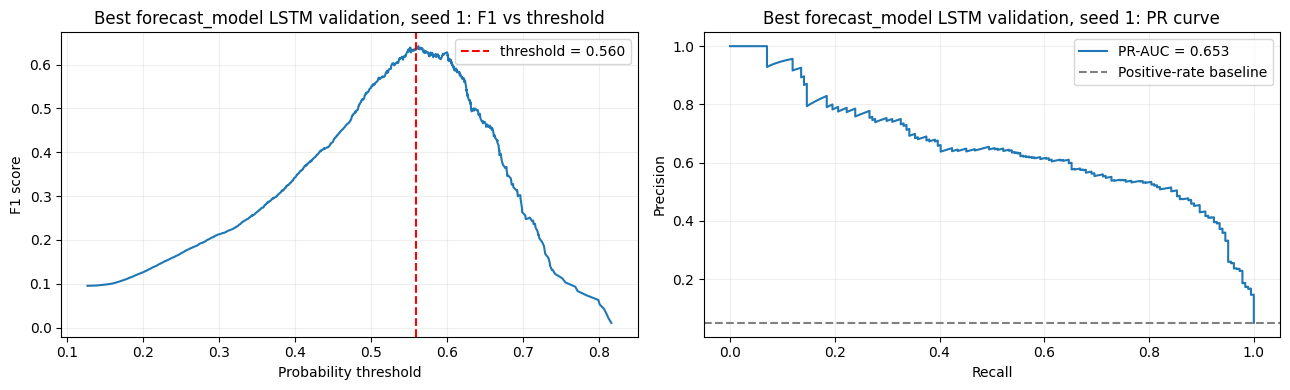

,best_threshold,best_f1,pr_auc
0,0.562777,0.642082,0.653336


In [15]:
# Run the selected configuration once for validation diagnostics.
datasets, _, _ = build_model_datasets(best_lookback)
diagnostic_result = run_tuning_config(
    current_config,
    datasets["forecast_model"],
    seed=1,
    return_predictions=True,
)
diagnostic_valid_true = diagnostic_result.pop("valid_true")
diagnostic_valid_prob = diagnostic_result.pop("valid_prob")

display(pd.DataFrame([diagnostic_result]))
validation_curve_summary = plot_threshold_and_pr_curve(
    diagnostic_valid_true,
    diagnostic_valid_prob,
    threshold=diagnostic_result["selected_threshold"],
    title="Best forecast_model LSTM validation, seed 1",
)
display(pd.DataFrame([validation_curve_summary]))


## Final Test Evaluation


,model,seed,lookback,hidden_dim,dropout,learning_rate,focal_alpha,focal_gamma,valid_PR_AUC,selected_valid_F1,selected_threshold,test_PR_AUC,test_ROC_AUC,test_F1_at_validation_threshold
0,forecast_model,1,72,32,0.0,0.003,0.5,4.0,0.653336,0.636559,0.56,0.841026,0.986295,0.725076
1,forecast_model,2,72,32,0.0,0.003,0.5,4.0,0.718646,0.657963,0.64,0.834567,0.986872,0.596639
2,forecast_model,3,72,32,0.0,0.003,0.5,4.0,0.696666,0.679666,0.64,0.876612,0.990201,0.726592


,mean,std
test_PR_AUC,0.850735,0.022642
test_F1_at_validation_threshold,0.682769,0.074595


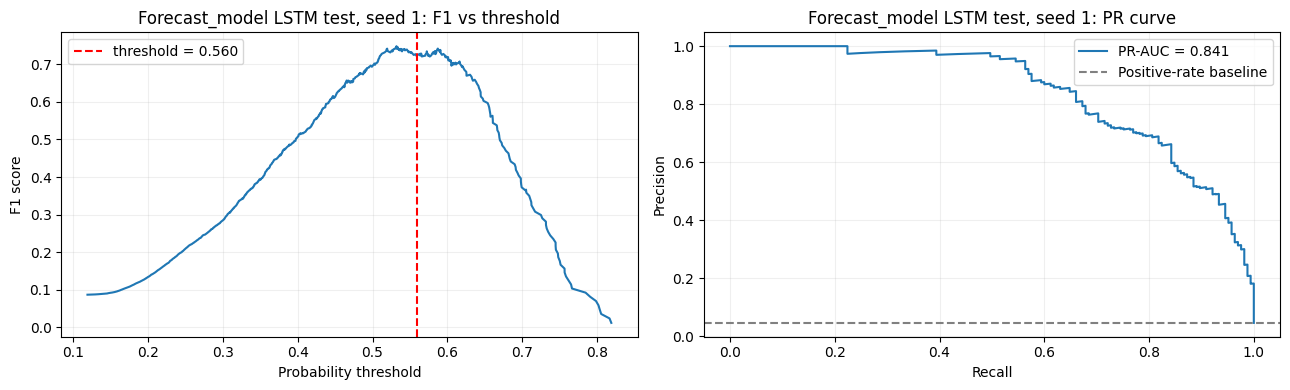

In [17]:
def evaluate_selected_config_on_test(data, config, seed):
    # Train on train only; validation selects the checkpoint and threshold.
    set_random_seed(seed)
    device = get_device()

    input_dim = data["X_train"].shape[2]
    model = CurtailmentLSTM(
        input_dim,
        hidden_dim=config["hidden_dim"],
        num_layers=num_layers,
        dropout=config["dropout"],
    ).to(device)

    num_pos = data["y_train"].sum()
    num_neg = len(data["y_train"]) - num_pos
    pos_weight = torch.tensor(
        [num_neg / max(num_pos, 1)],
        dtype=torch.float32,
        device=device,
    )
    criterion = make_loss(
        pos_weight=pos_weight,
        focal_alpha=config["focal_alpha"],
        focal_gamma=config["focal_gamma"],
    )
    optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])

    train_loader = make_loader(data["X_train"], data["y_train"], shuffle=True)
    valid_loader = make_loader(data["X_valid"], data["y_valid"], shuffle=False)
    test_loader = make_loader(data["X_test"], data["y_test"], shuffle=False)

    best_state = None
    best_valid_pr_auc = -np.inf
    epochs_without_improvement = 0

    for _ in range(epochs):
        train_epoch(model, train_loader, criterion, optimizer, device)
        valid_prob, valid_true = predict_probabilities(model, valid_loader, device)
        valid_pr_auc = average_precision_score(valid_true, valid_prob)

        if valid_pr_auc > best_valid_pr_auc:
            best_valid_pr_auc = valid_pr_auc
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_state)
    valid_prob, valid_true = predict_probabilities(model, valid_loader, device)
    selected_threshold, selected_valid_f1 = threshold_sweep(valid_true, valid_prob)
    test_prob, test_true = predict_probabilities(model, test_loader, device)

    return {
        "model": "forecast_model",
        "seed": seed,
        **config,
        "valid_PR_AUC": average_precision_score(valid_true, valid_prob),
        "selected_valid_F1": selected_valid_f1,
        "selected_threshold": selected_threshold,
        "test_PR_AUC": average_precision_score(test_true, test_prob),
        "test_ROC_AUC": roc_auc_score(test_true, test_prob),
        "test_F1_at_validation_threshold": f1_score(
            test_true,
            test_prob >= selected_threshold,
            zero_division=0,
        ),
        "test_true": test_true,
        "test_prob": test_prob,
    }


datasets, _, _ = build_model_datasets(current_config["lookback"])
final_forecast_data = datasets["forecast_model"]

final_results = []
final_predictions = {}
for seed in seeds:
    result = evaluate_selected_config_on_test(
        final_forecast_data,
        config=current_config,
        seed=seed,
    )
    final_predictions[seed] = {
        "test_true": result.pop("test_true"),
        "test_prob": result.pop("test_prob"),
        "threshold": result["selected_threshold"],
    }
    final_results.append(result)

final_test_results_df = pd.DataFrame(final_results)
final_test_summary = final_test_results_df.agg({
    "test_PR_AUC": ["mean", "std"],
    "test_F1_at_validation_threshold": ["mean", "std"],
}).T

display(final_test_results_df)
display(final_test_summary)

plot_seed = 1
plot_prediction = final_predictions[plot_seed]
test_curve_summary = plot_threshold_and_pr_curve(
    plot_prediction["test_true"],
    plot_prediction["test_prob"],
    threshold=plot_prediction["threshold"],
    title="Forecast_model LSTM test, seed 1",
)
